<a href="https://colab.research.google.com/github/Ankan2309/Ankan2309/blob/main/Forecast_bikeshare_demand_using_time_series_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import warnings

warnings.filterwarnings('ignore')

In [20]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [21]:
import pandas as pd # Ensure pandas is imported here for read_csv
import os

train_csv_path = '/content/train.csv'
test_csv_path = '/content/test.csv'

if os.path.exists(train_csv_path) and os.path.exists(test_csv_path):
    print(f"'{train_csv_path}' and '{test_csv_path}' found. Proceeding with data loading.")
    train = pd.read_csv(train_csv_path)
    test = pd.read_csv(test_csv_path)

    print(f"Train data shape: {train.shape}")
    print(f"Test data shape: {test.shape}")

    print("\nFirst 5 rows of train data:")
    display(train.head()) # Use display for better output in Colab
else:
    print(f"'{train_csv_path}' or '{test_csv_path}' not found. Please upload the 'train.csv' and 'test.csv' files to the '/content/' directory.")
    print("Once uploaded, run this cell again.")

'/content/train.csv' and '/content/test.csv' found. Proceeding with data loading.
Train data shape: (10886, 12)
Test data shape: (6493, 9)

First 5 rows of train data:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [22]:
import os

zip_file_path = '/kaggle/input/competitions/bike-sharing-demand'
if os.path.exists(zip_file_path):
    print(f"'{zip_file_path}' found. You can proceed with unzipping.")
else:
    print(f"'{zip_file_path}' not found. Please ensure it's uploaded to the correct location.")

'/kaggle/input/competitions/bike-sharing-demand' not found. Please ensure it's uploaded to the correct location.


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
train.sample(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
4590,2011-11-04 08:00:00,4,0,1,2,16.40,20.455,87,23.9994,8,387,395
2403,2011-06-08 01:00:00,2,0,1,1,27.06,30.305,78,0.0000,3,20,23
4205,2011-10-07 06:00:00,4,0,1,1,17.22,21.210,88,0.0000,3,84,87
3698,2011-09-05 00:00:00,3,1,0,2,28.70,33.335,74,15.0013,31,66,97
9904,2012-10-17 01:00:00,4,0,1,1,15.58,19.695,76,0.0000,3,14,17


In [25]:
test.sample(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
4775,2012-06-27 19:00:00,3,0,1,1,31.98,34.090,29,22.0028
3583,2012-02-23 02:00:00,1,0,1,2,18.04,21.970,62,15.0013
3705,2012-02-28 04:00:00,1,0,1,1,13.12,14.395,42,23.9994
1158,2011-05-26 06:00:00,2,0,1,2,24.60,25.000,100,6.0032
6176,2012-11-29 17:00:00,4,0,1,1,13.94,16.665,39,12.9980


In [26]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [27]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB


In [28]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [29]:
train.drop_duplicates(inplace= True)

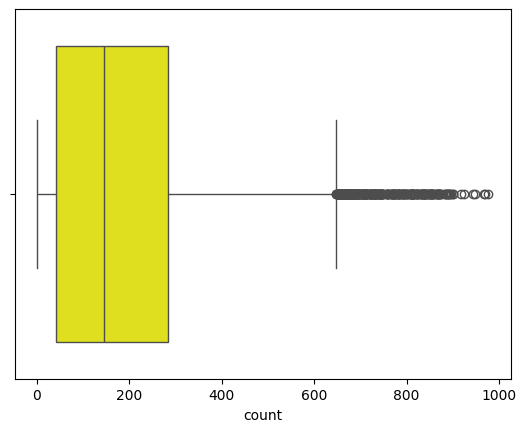

In [30]:
import seaborn as sns
sns.boxplot(x='count', data=train, color='yellow')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

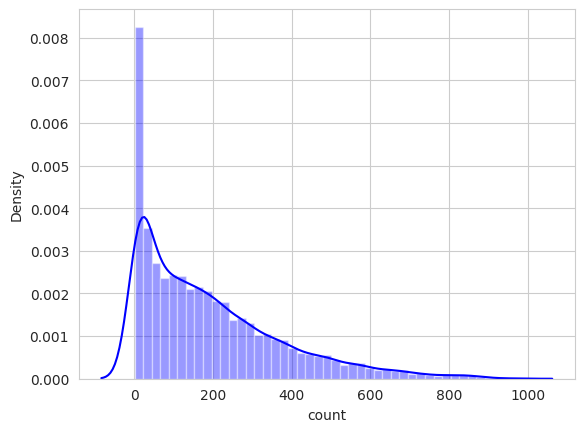

In [31]:
from scipy.__config__ import show
sns.set_style('whitegrid')
sns.distplot(train['count'], color='blue')
plt.show

In [32]:
fields = [i for i in train]
fields=fields[5:9]
print(fields)

['temp', 'atemp', 'humidity', 'windspeed']


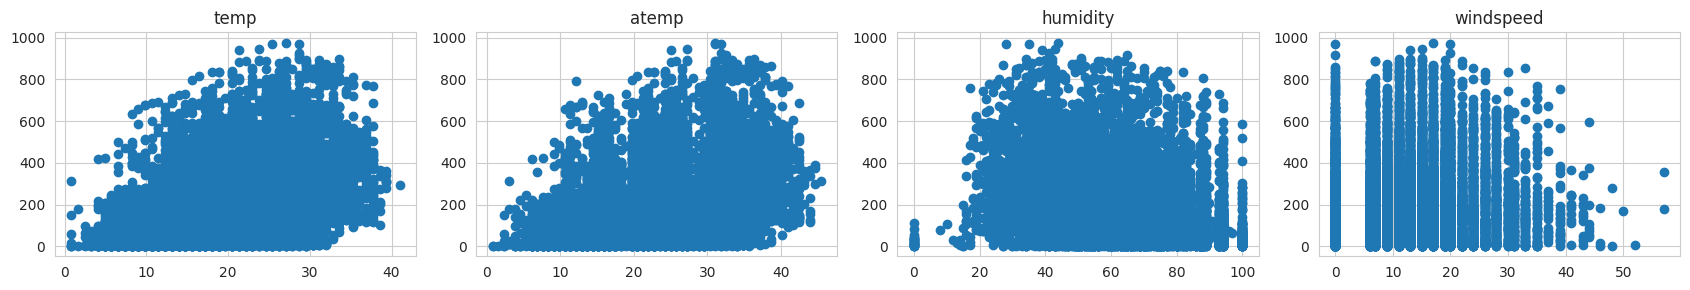

In [33]:
fig = plt.figure(figsize=(17,3))
for i,f in enumerate(fields):
  ax = fig.add_subplot(1,4,i+1)
  ax.scatter(train[f], train['count'])
  ax.set_title(f)
plt.tight_layout()

<Axes: xlabel='workingday', ylabel='count'>

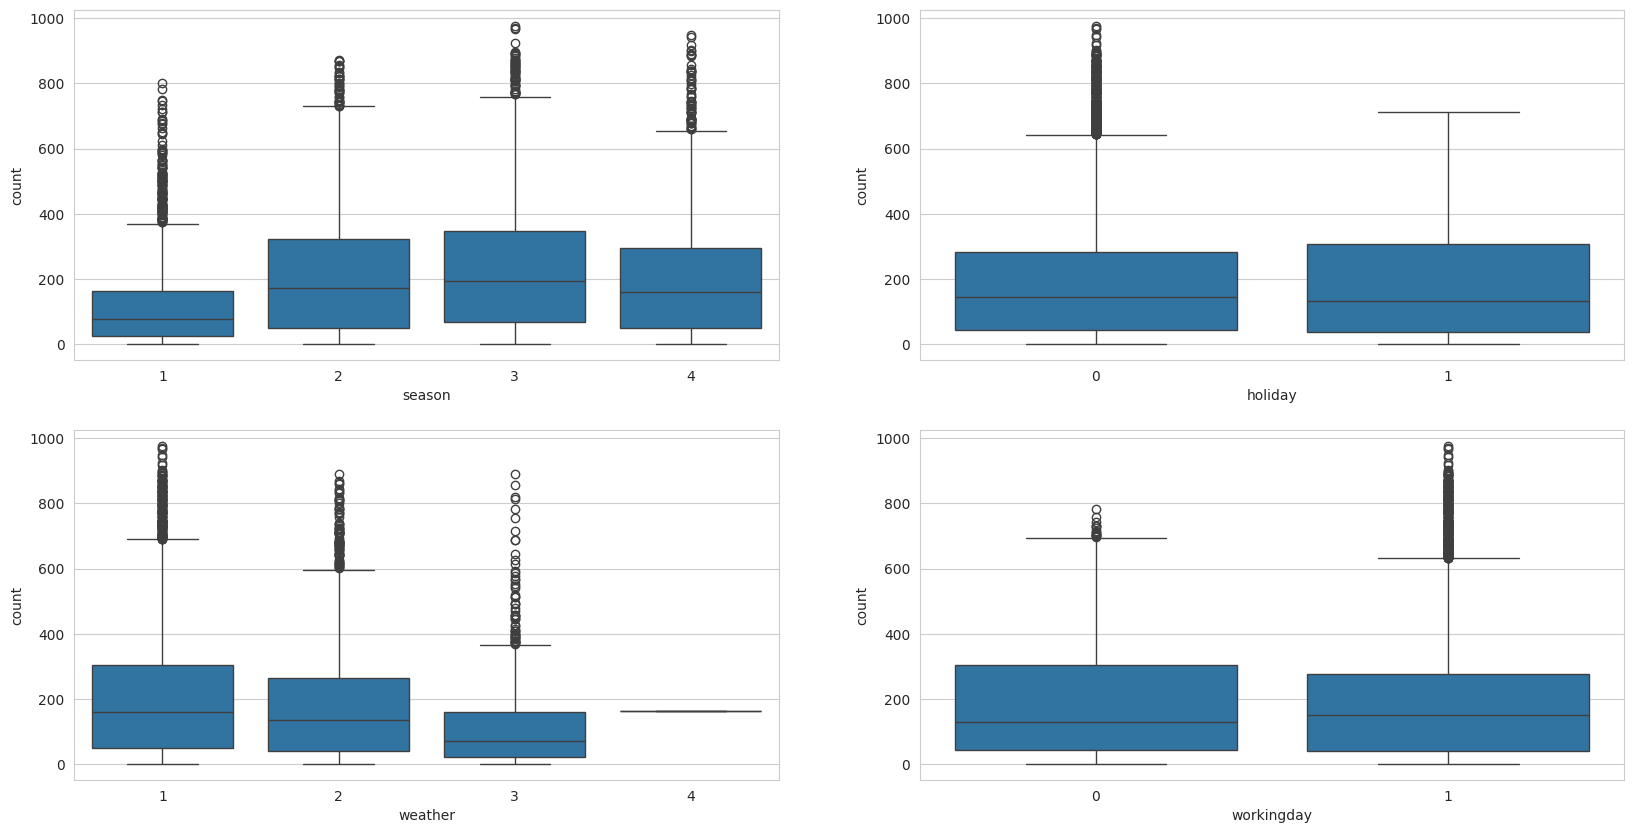

In [34]:
fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
fig.set_size_inches(20,10)

sns.boxplot(x='season', y='count', data=train, ax=axes[0,0])
sns.boxplot(x='holiday',y='count', data=train, ax=axes[0,1])
sns.boxplot(x='weather',y='count', data=train, ax=axes[1,0])
sns.boxplot(x='workingday',y='count', data=train, ax=axes[1,1])

<Axes: xlabel='workingday', ylabel='count'>

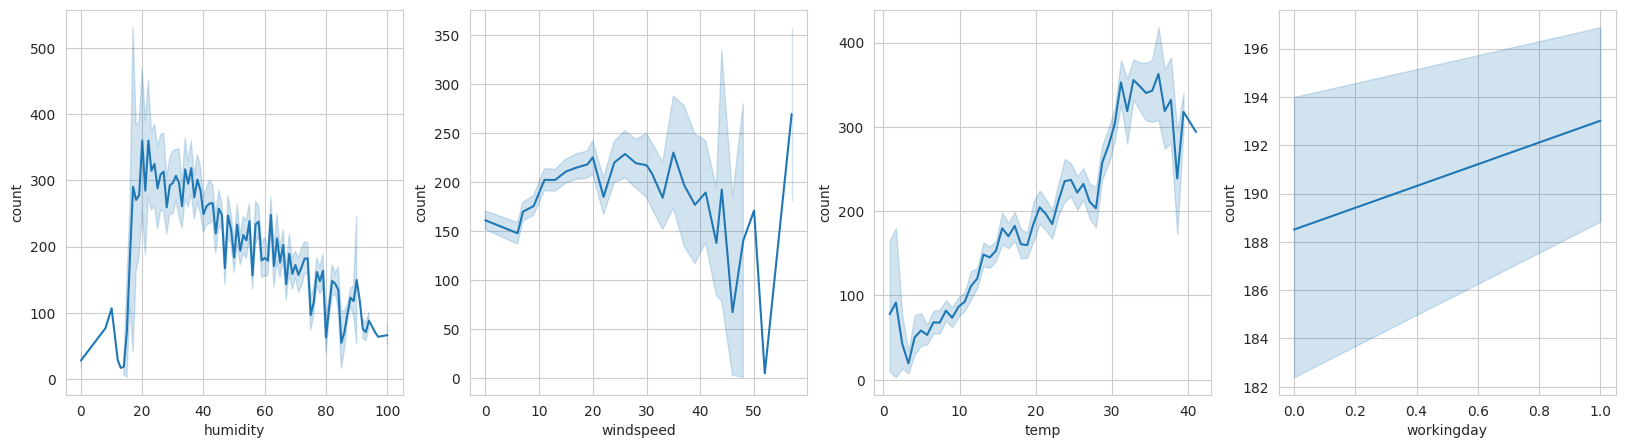

In [35]:
fig, axs = plt.subplots(1,4)
fig.set_size_inches (20,5)
sns.lineplot(data=train, x="windspeed", y="count", ax=axs[1])
sns.lineplot(data=train, x="humidity", y="count", ax=axs[0])
sns.lineplot(data=train, x="temp", y="count", ax=axs[2])
sns.lineplot(data=train, x="workingday", y="count", ax=axs [3])


<Axes: >

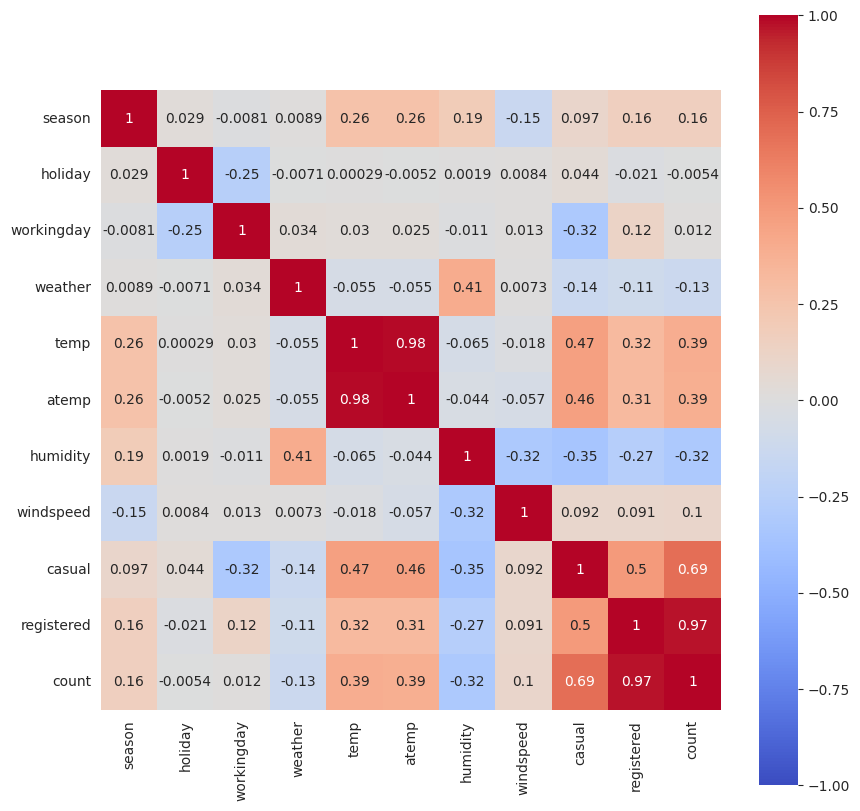

In [36]:
plt.figure(figsize=(10,10))
sns.heatmap(train.select_dtypes(include=np.number).corr(), vmin=-1, vmax=1, cmap='coolwarm', annot=True, square = True)

In [37]:
train['datetime']= pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt
test['datetime']= pd.to_datetime(test['datetime'])
test['year'] = test['datetime'].dt.year
test['month'] = test['datetime'].dt

In [38]:
train.sample(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month
6015,2012-02-06 21:00:00,1,0,1,1,13.12,15.910,57,11.0014,11,143,154,2012,<pandas.core.indexes.accessors.DatetimePropert...
63,2011-01-03 18:00:00,1,0,1,1,9.84,12.880,32,7.0015,9,148,157,2011,<pandas.core.indexes.accessors.DatetimePropert...
188,2011-01-09 03:00:00,1,0,0,1,4.10,3.790,46,27.9993,0,4,4,2011,<pandas.core.indexes.accessors.DatetimePropert...
9967,2012-10-19 16:00:00,4,0,1,3,25.42,30.305,69,23.9994,131,434,565,2012,<pandas.core.indexes.accessors.DatetimePropert...
6597,2012-03-12 04:00:00,1,0,1,1,13.94,16.665,61,12.9980,0,3,3,2012,<pandas.core.indexes.accessors.DatetimePropert...


In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(1), int64(8), object(1)
memory usage: 1.1+ MB


In [40]:
test.sample(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month
2654,2011-10-31 03:00:00,4,0,1,1,9.84,12.880,87,7.0015,2011,<pandas.core.indexes.accessors.DatetimePropert...
5959,2012-11-20 15:00:00,4,0,1,2,18.86,22.725,55,7.0015,2012,<pandas.core.indexes.accessors.DatetimePropert...
3957,2012-03-28 17:00:00,2,0,1,1,24.60,30.305,60,15.0013,2012,<pandas.core.indexes.accessors.DatetimePropert...
4980,2012-07-25 08:00:00,3,0,1,1,28.70,31.820,42,16.9979,2012,<pandas.core.indexes.accessors.DatetimePropert...
724,2011-03-31 04:00:00,2,0,1,3,9.84,11.365,93,16.9979,2011,<pandas.core.indexes.accessors.DatetimePropert...


In [41]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[ns]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
 9   year        6493 non-null   int32         
 10  month       6493 non-null   object        
dtypes: datetime64[ns](1), float64(3), int32(1), int64(5), object(1)
memory usage: 532.8+ KB


In [42]:
import pandas as pd

# Ensure train DataFrame is loaded and datetime column is processed if not already
# This part duplicates code from earlier cells to make this cell runnable in isolation if needed.
try:
    if 'train' not in locals() or not isinstance(train, pd.DataFrame) or 'datetime' not in train.columns:
        train = pd.read_csv("/content/train.csv")
        train['datetime'] = pd.to_datetime(train['datetime'])
except FileNotFoundError:
    print("Error: train.csv not found. Please ensure the dataset is unzipped at /content/.")
    raise

train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['dayofweek']= train['datetime'].dt.dayofweek
train['hour'] = train['datetime'].dt.hour

In [43]:
train.sample(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,hour
6295,2012-02-18 13:00:00,1,0,0,1,16.40,20.455,43,19.0012,165,219,384,2012,2,18,5,13
302,2011-01-14 01:00:00,1,0,1,1,4.10,6.060,54,11.0014,0,5,5,2011,1,14,4,1
6484,2012-03-07 10:00:00,1,0,1,1,14.76,16.665,50,19.9995,20,127,147,2012,3,7,2,10
10686,2012-12-11 16:00:00,4,0,1,2,15.58,19.695,50,15.0013,24,334,358,2012,12,11,1,16
8402,2012-07-11 11:00:00,3,0,1,2,31.16,35.605,58,8.9981,56,173,229,2012,7,11,2,11


In [44]:
train=train.drop(['datetime'], axis=1)
train= train.drop(['casual'], axis=1)
train= train.drop(['registered'], axis=1)

In [45]:
train.sample(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,dayofweek,hour
10649,4,0,1,2,15.58,19.695,94,7.0015,4,2012,12,10,0,3
2537,2,0,1,1,28.70,31.820,37,30.0026,185,2011,6,13,0,15
4634,4,0,0,1,9.84,14.395,87,0.0000,6,2011,11,6,6,4
682,1,0,1,1,11.48,15.910,28,0.0000,174,2011,2,11,4,18
1689,2,0,0,2,16.40,20.455,82,27.9993,21,2011,4,16,5,7


In [46]:
test['year'] = pd.to_datetime(test['datetime']).dt.year
test['month'] = pd.to_datetime(test['datetime']).dt.month
test['day'] = pd.to_datetime(test['datetime']).dt.day
test['dayofweek']= pd.to_datetime(test['datetime']).dt.dayofweek
test['hour'] = pd.to_datetime(test['datetime']).dt.hour

In [47]:
test=test.drop(['datetime'], axis=1)

In [48]:
test.sample(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
5139,3,0,1,2,27.06,30.305,83,11.0014,2012,7,31,1,23
4861,3,0,1,2,28.70,33.335,79,8.9981,2012,7,20,4,9
3563,1,0,1,1,13.12,15.910,76,11.0014,2012,2,22,2,6
6342,1,1,0,2,13.12,15.150,57,16.9979,2012,12,25,1,17
3833,2,0,1,2,28.70,32.575,48,0.0000,2012,3,23,4,13


In [49]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int32  
 10  month       10886 non-null  int32  
 11  day         10886 non-null  int32  
 12  dayofweek   10886 non-null  int32  
 13  hour        10886 non-null  int32  
dtypes: float64(3), int32(5), int64(6)
memory usage: 978.2 KB


In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      6493 non-null   int64  
 1   holiday     6493 non-null   int64  
 2   workingday  6493 non-null   int64  
 3   weather     6493 non-null   int64  
 4   temp        6493 non-null   float64
 5   atemp       6493 non-null   float64
 6   humidity    6493 non-null   int64  
 7   windspeed   6493 non-null   float64
 8   year        6493 non-null   int32  
 9   month       6493 non-null   int32  
 10  day         6493 non-null   int32  
 11  dayofweek   6493 non-null   int32  
 12  hour        6493 non-null   int32  
dtypes: float64(3), int32(5), int64(5)
memory usage: 532.8 KB


<Axes: xlabel='hour', ylabel='count'>

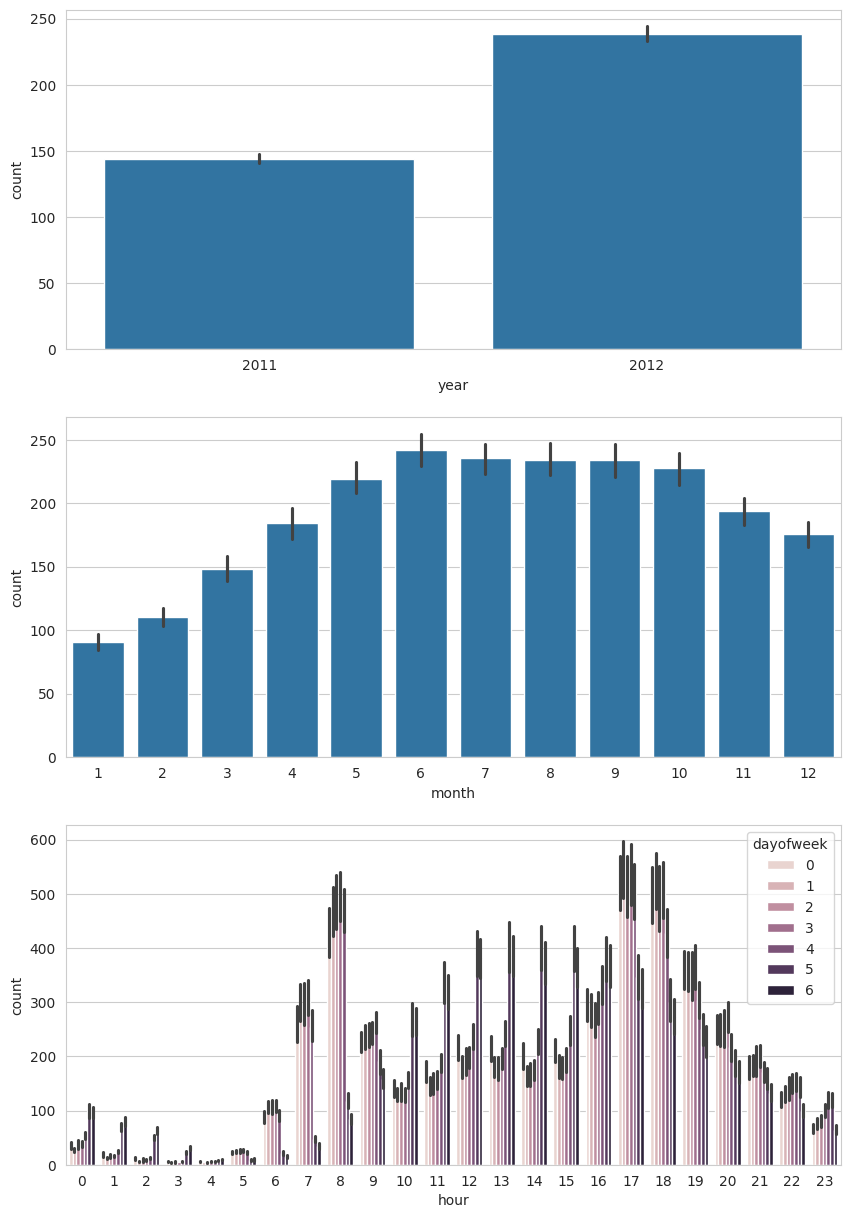

In [51]:
fig, axes = plt.subplots (nrows=3, ncols=1)
fig.set_size_inches(10,15)
sns.barplot(data=train,x='year', y='count', ax=axes[0])
sns.barplot(data=train,x='month', y='count', ax=axes[1])
sns.barplot(data=train,x='hour', y='count', ax=axes [2], hue='dayofweek')

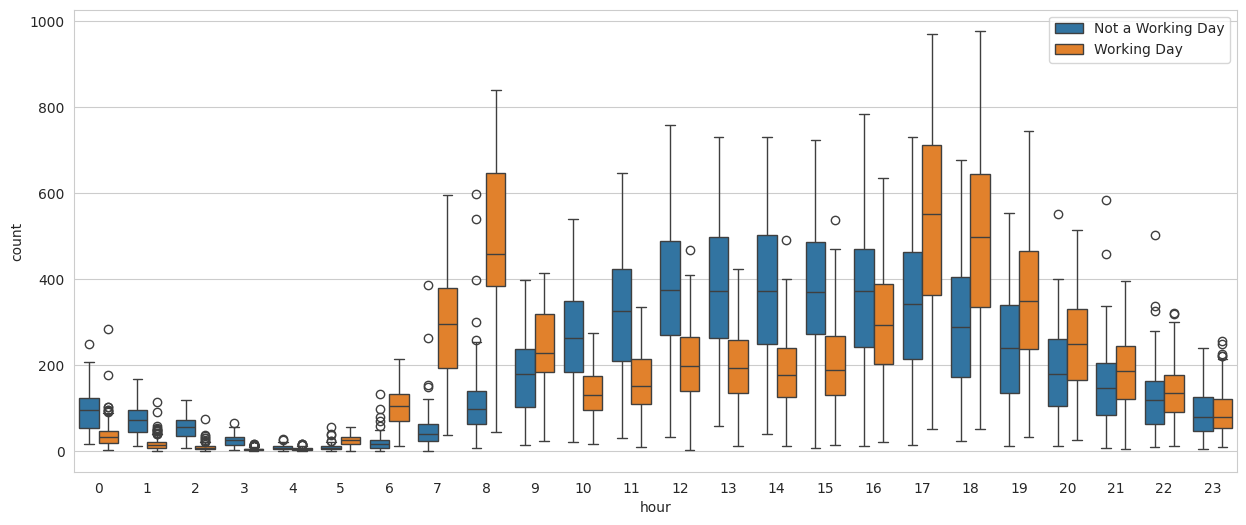

In [52]:
f, axes = plt.subplots(1, 1, figsize=(15,6))
sns.boxplot(data=train, y='count', x='hour', hue='workingday', ax=axes)
handles,_ = axes.get_legend_handles_labels()
axes.legend(handles, ['Not a Working Day', 'Working Day'])
plt.show()

In [53]:
import plotly.express as px

figl = px.bar(train, x="weather", y="count")
fig2 = px.bar(train, x="windspeed", y="count")
fig3 = px.bar(train, x="humidity", y="count")
fig4 = px.bar(train, x="temp", y="count")

figl.update_traces (marker_line_width=0)
fig2.update_traces (marker_line_width=0)
fig3.update_traces (marker_line_width=0)
fig4.update_traces (marker_line_width=0)

figl.show()
fig2.show()
fig3.show()
fig4.show()

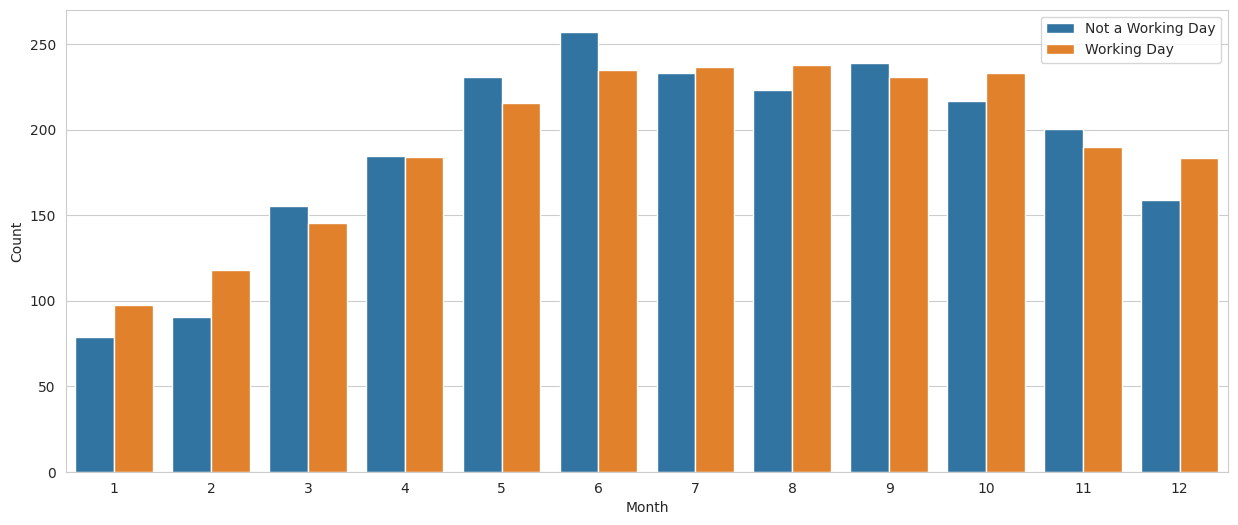

In [54]:
f, axes = plt.subplots (nrows=1, ncols=1, figsize=(15,6))
group_month= pd.DataFrame(train.groupby(['month', 'workingday']) ['count'].mean()).reset_index()
sns.barplot(data=group_month, x='month', y='count', hue='workingday', ax=axes)
axes.set(xlabel='Month', ylabel='Count')
handles,_ = axes.get_legend_handles_labels()
axes.legend(handles, ['Not a Working Day', 'Working Day'])
plt.show()

<Axes: xlabel='count', ylabel='Count'>

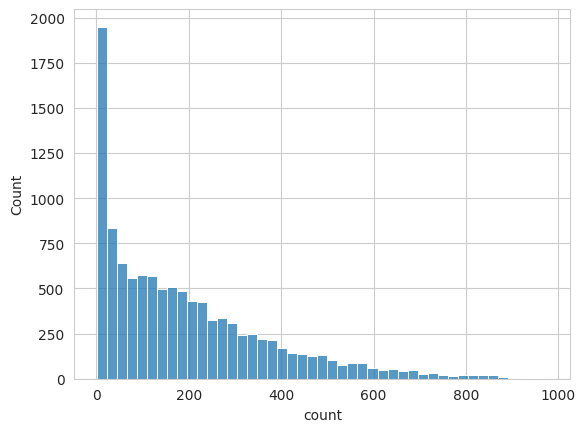

In [55]:
sns.histplot(train['count'])

In [56]:
train['count']=np.log1p(train['count'])

<Axes: xlabel='count', ylabel='Count'>

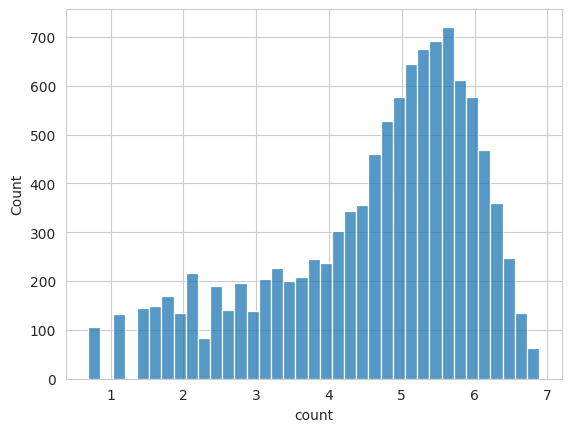

In [57]:
sns.histplot(train['count'])

In [58]:
train=train[np.abs(train['count'])-train['count'].mean()<=(3*train['count'].std())]

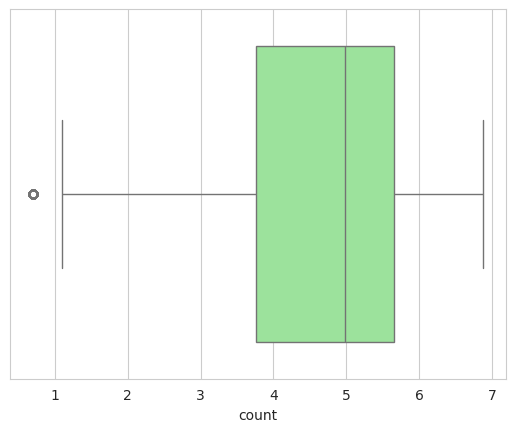

In [59]:
sns.boxplot(x='count', data=train, color='lightgreen')
plt.show()

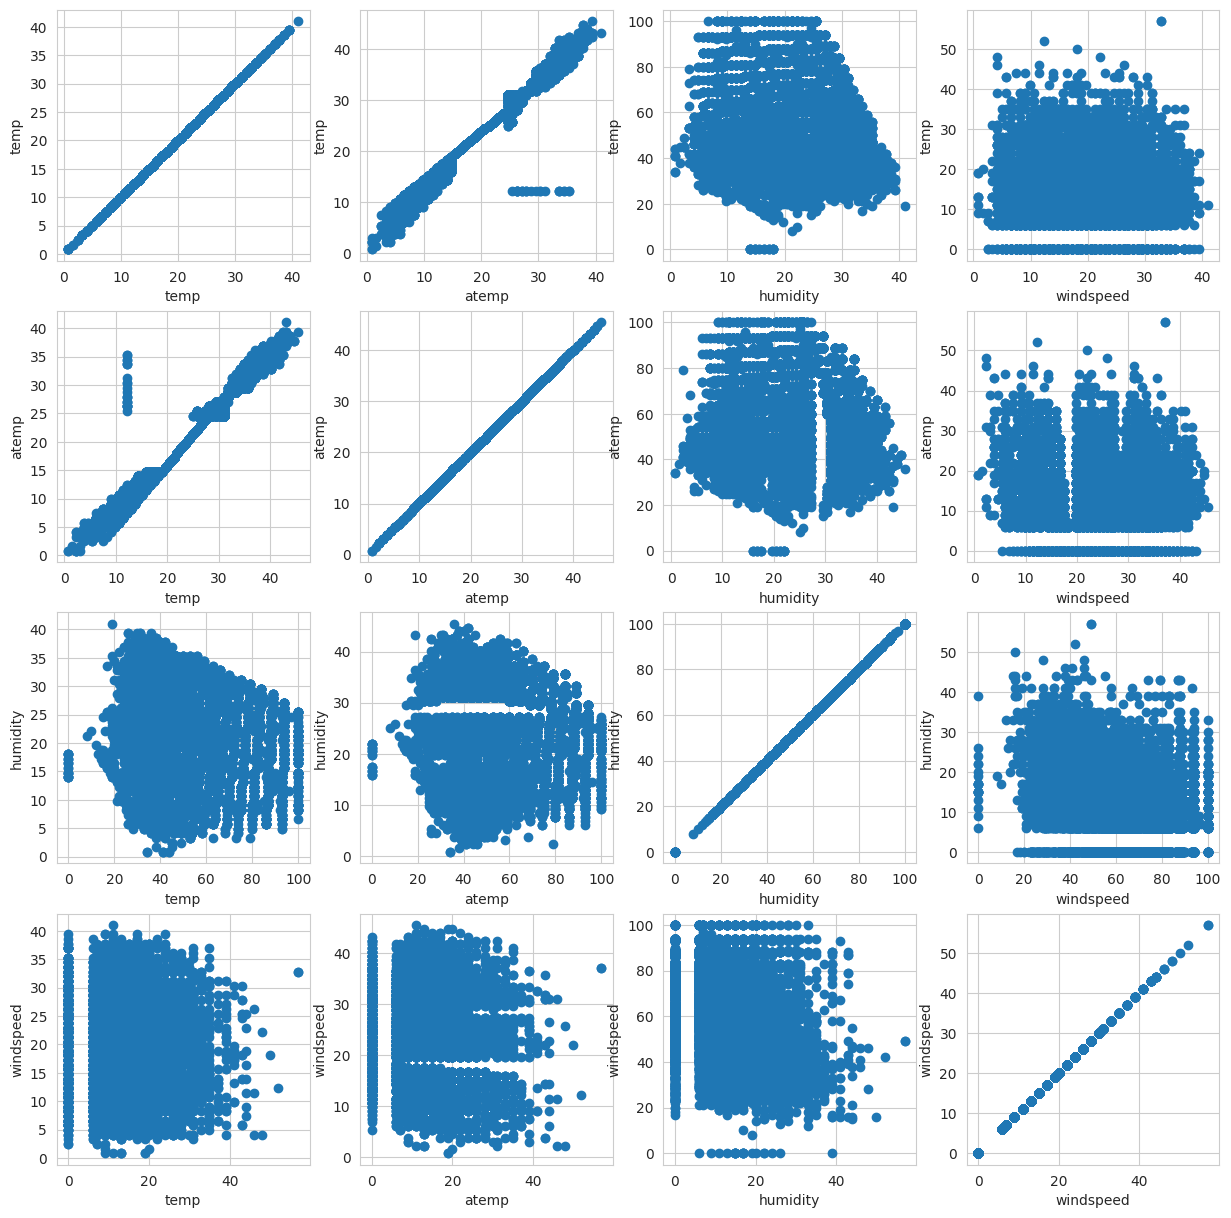

In [60]:
fig=plt.figure(figsize=(15,15))
for i,fl in enumerate(fields):
   for j,f2 in enumerate(fields):
       idx =i*len(fields)+j+1
       ax=fig.add_subplot(len(fields), len (fields), idx)
       ax.scatter(train[fl], train[f2])
       ax.set_ylabel(fl)
       ax.set_xlabel(f2)
plt.show()

In [61]:
drop_idx = train[(train['atemp']>20) & (train['atemp']<40) & (train['temp']>10) & (train['temp']<20)].index
train =train.drop(drop_idx)
from sklearn.preprocessing import MinMaxScaler
def scaling(df):
  scaler= MinMaxScaler()
  num_cols= ['temp', 'atemp', 'humidity', 'windspeed'] # Corrected: 'temp', 'atemp' should be separate strings
  df[num_cols]=scaler.fit_transform(df[num_cols])
  return df
train =scaling(train)
test = scaling(test)
train.sample(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,dayofweek,hour
5673,1,0,1,3,0.306122,0.372860,0.76,0.000000,4.189655,2012,1,11,2,13
9222,3,0,1,1,0.795918,0.830518,0.55,0.298225,5.805135,2012,9,7,4,15
1041,1,0,1,1,0.244898,0.271171,0.48,0.193018,3.583519,2011,3,7,0,22
4326,4,0,1,2,0.530612,0.559347,0.88,0.456213,5.560682,2011,10,12,2,7
2252,2,0,1,3,0.816327,0.864414,0.56,0.456213,5.736572,2011,6,1,2,18


In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(train.drop(['count'],axis=1),train['count'], test_size =0.3)

def rmsle(y,pred):
    log_y =np.log1p(y)
    log_pred=np.log1p(pred)
    squared_error = (log_y - log_pred)**2
    remsle =np.sqrt(np.mean(squared_error))
    return remsle

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [67]:
def evaluate(reg_cls,params=None):
    reg=reg_cls()
    if params:
       reg=GridSearchCV(reg,param_grid=params,refit = True)
    reg.fit(X_train, Y_train)
    pred=reg.predict(X_test)
    print(findmae(Y_test, pred))
    score =reg.score(X_test, Y_test)*100
    print(score)
    y_test_exp = np.expm1(Y_test)
    pred_exp=np.expm1(pred)

    print('\n',reg_cls)
    if params:
       print(reg.best_params_)
       reg=reg.best_estimator_
    print(rmsle(y_test_exp,pred_exp))
    return reg, pred_exp

from sklearn.metrics import mean_absolute_error as mae
def findmae(Y_test,pred):
    return mae(Y_test, pred)

In [70]:
print("--LinearRegression---")
lr_reg, pred_lr = evaluate (LinearRegression)
print("--Ridge--")
rg_reg, pred_rg = evaluate (Ridge)
print("---Lasso---")
ls_reg, pred_ls = evaluate (Lasso)
print("---Random ForestRegressor---")
rf_reg, pred_rf = evaluate (RandomForestRegressor)
print("----GradientBoosting Regressor-----")
gb_reg, pred_gb = evaluate (GradientBoostingRegressor)
print("---XGBRegressor--------")
xg_reg, pred_xg = evaluate (XGBRegressor)
print(". ---LGBMRegressor-")
lg_reg, pred_lg = evaluate (LGBMRegressor)
params ={'n_estimators': [100*i for i in range(1,6)]}
print("---XGBRegressor")
xg_reg, pred_xg = evaluate (XGBRegressor, params)
print("LGBMRegressor-----")
lg_reg, pred_lg = evaluate (LGBMRegressor, params)

--LinearRegression---
0.794184417634456
49.79310447043428

 <class 'sklearn.linear_model._base.LinearRegression'>
1.006973072621561
--Ridge--
0.7944477678198945
49.784963660922635

 <class 'sklearn.linear_model._ridge.Ridge'>
1.0070547072616693
---Lasso---
0.9629435903945106
31.698564255823282

 <class 'sklearn.linear_model._coordinate_descent.Lasso'>
1.1744947765515896
---Random ForestRegressor---
0.2037302859605829
95.2628709807454

 <class 'sklearn.ensemble._forest.RandomForestRegressor'>
0.30930987094053
----GradientBoosting Regressor-----
0.30016095432390133
91.75871144450608

 <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
0.40797517128267896
---XGBRegressor--------
0.20139393090541025
95.4776210352499

 <class 'xgboost.sklearn.XGBRegressor'>
0.3022175284450496
. ---LGBMRegressor-
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

<class 'lightgbm.sklearn.LGBMRegressor'>


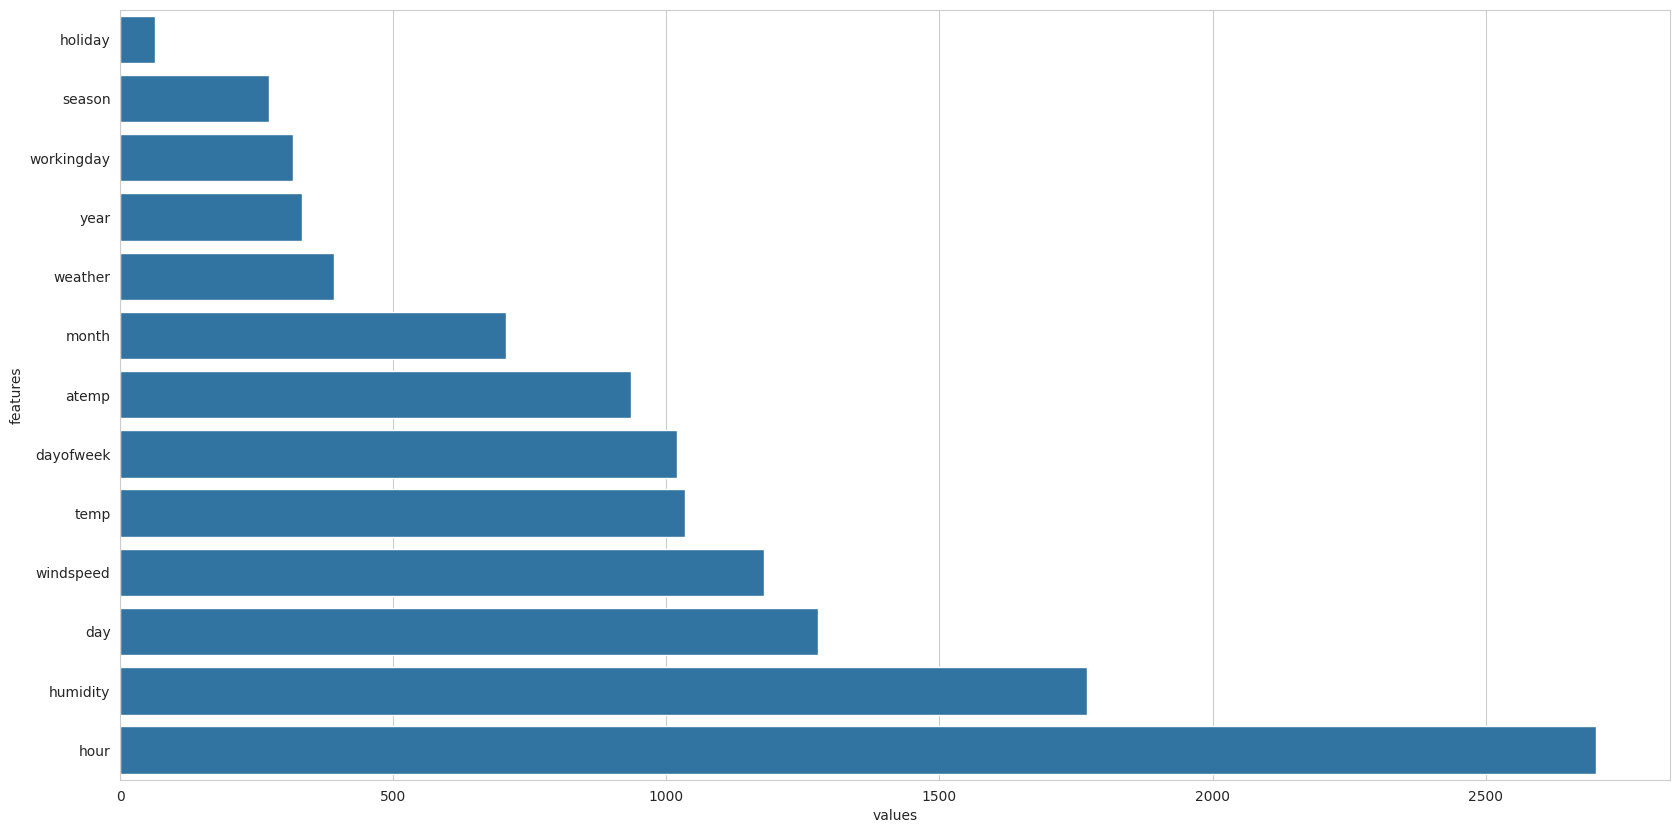

In [69]:
def feature_importance(reg):
    plt.figure(figsize=(20,10))
    print(type(reg))
    df=pd.DataFrame(sorted(zip(X_train.columns, reg.feature_importances_)),columns=['features', 'values'])
    sns.barplot(x='values',y='features', data=df.sort_values (by='values', ascending=True))
    plt.show()

feature_importance (lg_reg)

In [71]:
submission = pd.read_csv('/content/sampleSubmission.csv')
submission.sample(5)

,datetime,count
1742,2011-07-27 14:00:00,0
5124,2012-07-31 08:00:00,0
5965,2012-11-20 21:00:00,0
5603,2012-09-27 07:00:00,0
3393,2012-01-27 02:00:00,0


In [76]:
test.shape

(6493, 13)

In [77]:
submission.shape

(6493, 2)

In [74]:
pred = lg_reg.predict(test)
pred_exp= np.expm1(pred)
print(pred_exp)

[ 10.52555209   4.82596871   3.43122606 ... 131.59899891  81.85935836
  50.17259534]


In [78]:
submission.loc[:, 'count'] = pred_exp
submission

,datetime,count
0,2011-01-20 00:00:00,10.525552
1,2011-01-20 01:00:00,4.825969
2,2011-01-20 02:00:00,3.431226
3,2011-01-20 03:00:00,2.024445
4,2011-01-20 04:00:00,1.517153
...,...,...
6488,2012-12-31 19:00:00,255.158219
6489,2012-12-31 20:00:00,183.217227
6490,2012-12-31 21:00:00,131.598999
6491,2012-12-31 22:00:00,81.859358


In [81]:
submission.to_csv(r'C:\Users\ankan\Music\result', sep='\t')